# Lib1 Held-Out Test-Quality Evaluation (May 13, 2026)

This notebook focuses only on the random mixed-training run with quality-resolved held-out test bins. It compares `branched_only` and `full` unfreeze scopes for the same seeds, training sizes, B2 setting, and test-quality bins.

Use `SCOPES_TO_PLOT` near the top to limit plots to one scope, e.g. `["full"]`, when you want a lighter rerun.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
try:
    from IPython.display import display, Markdown
except ModuleNotFoundError:
    def display(obj=None, *args, **kwargs):
        print(obj)

    class Markdown(str):
        pass

pd.set_option("display.max_columns", 220)
pd.set_option("display.max_rows", 140)
pd.set_option("display.width", 240)

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

REPO_ROOT = Path("/home/minhang/synBio_AL/boda2_EU")
LC_ROOT = REPO_ROOT / "src/finetune/learning_curve"

RUN_SPECS = {
    "random_quality": {
        "label": "Random mixed train, quality-resolved test",
        "kind": "quality",
        "dir_name": "lib1_enhancer_random_train_test_quality_finebins_cap3000_b2_may2026",
        "extra_dir_names": [
            "lib1_enhancer_random_train_test_quality_finebins_cap3000_b2_full_may2026",
        ],
    },
}

UNFREEZE_SCOPE_ORDER = ["branched_only", "full"]
# Edit this list if you only want one scope's plots, e.g. ["full"].
SCOPES_TO_PLOT = ["branched_only", "full"]
DEFAULT_UNFREEZE_SCOPE = "branched_only"

SPLIT_ORDER = ["train", "val", "test"]

METRIC_SPECS = {
    "cod_r2": {
        "label": "COD R2",
        "higher_is_better": True,
        "cols": {"train": "train_r2_cod", "val": "val_r2_cod", "test": "test_r2_cod"},
        "margin": 0.02,
    },
    "pearson": {
        "label": "Pearson r",
        "higher_is_better": True,
        "cols": {"train": "train_pearson", "val": "val_pearson", "test": "test_pearson"},
        "margin": 0.02,
    },
    "spearman": {
        "label": "Spearman rho",
        "higher_is_better": True,
        "cols": {"train": "train_spearman", "val": "val_spearman", "test": "test_spearman"},
        "margin": 0.02,
    },
    "loss": {
        "label": "MSE loss, std target",
        "higher_is_better": False,
        "cols": {
            "train": "train_loss_standardized",
            "val": "val_loss_standardized",
            "test": "test_loss_standardized",
        },
        "margin": 0.02,
    },
}
METRIC_ROOTS = tuple(METRIC_SPECS)
METRIC_LABEL_ORDER = [METRIC_SPECS[m]["label"] for m in METRIC_ROOTS]
ERROR_BAND_ALPHA = 0.13

RANGE_BIN_LABEL_ORDER = ["1-3 barcodes", "4-6 barcodes", ">=7 barcodes"]
EXACT_BIN_LABEL_ORDER = ["1 barcode", "2 barcodes", "3 barcodes", "4-6 barcodes", ">=7 barcodes"]
QUALITY_LABEL_ORDER = [
    "test: 1-2 barcodes",
    "test: 3-4 barcodes",
    "test: 5-6 barcodes",
    "test: 7-8 barcodes",
    "test: >=9 barcodes",
]

RANGE_BIN_PALETTE = {
    "1-3 barcodes": "#0072B2",
    "4-6 barcodes": "#D55E00",
    ">=7 barcodes": "#5D3A9B",
}
EXACT_BIN_PALETTE = {
    "1 barcode": "#0072B2",
    "2 barcodes": "#56B4E9",
    "3 barcodes": "#009E73",
    "4-6 barcodes": "#D55E00",
    ">=7 barcodes": "#5D3A9B",
}
QUALITY_PALETTE = dict(zip(QUALITY_LABEL_ORDER, sns.color_palette("colorblind", len(QUALITY_LABEL_ORDER))))
SPLIT_PALETTE = {"train": "#0072B2", "val": "#E69F00", "test": "#CC79A7"}

## Load combined outputs

These cells read the combined CSVs and append matching `full` and `branched_only` output directories in memory. Split plans and zero-shot baseline tables are kept from the primary directory because they do not depend on unfreeze scope.

In [2]:
def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def read_json_required(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(path)
    with path.open() as handle:
        return json.load(handle)


def annotate_bundle_frame(frame: pd.DataFrame, *, key: str, label: str, run_dir: Path | None = None) -> pd.DataFrame:
    out = frame.copy()
    out["run_key"] = key
    out["run_label"] = label
    if run_dir is not None:
        out["result_dir_name"] = run_dir.name
    return out


def load_run_bundle(key: str, spec: dict) -> dict:
    dir_names = [spec["dir_name"], *spec.get("extra_dir_names", [])]
    run_dirs = [LC_ROOT / dir_name for dir_name in dir_names]
    combined_dirs = [run_dir / "combined" for run_dir in run_dirs]

    run_parts = []
    history_parts = []
    manifests = []
    planned = None
    zero_shot = None
    for run_dir, combined_dir in zip(run_dirs, combined_dirs):
        run_parts.append(
            annotate_bundle_frame(
                read_csv_required(combined_dir / "learning_curve_runs.csv"),
                key=key,
                label=spec["label"],
                run_dir=run_dir,
            )
        )
        history_parts.append(
            annotate_bundle_frame(
                read_csv_required(combined_dir / "learning_curve_histories.csv"),
                key=key,
                label=spec["label"],
                run_dir=run_dir,
            )
        )
        manifests.append(read_json_required(combined_dir / "run_manifest_combined.json"))

        # Split plans and zero-shot baselines do not depend on unfreeze scope.
        # Keep the primary run's copy to avoid duplicate rows after appending full-scope outputs.
        if planned is None:
            barcode_grid_path = combined_dir / "barcode_range_planned_grid.csv"
            quality_grid_path = combined_dir / "quality_split_planned_grid.csv"
            if barcode_grid_path.exists():
                planned = annotate_bundle_frame(read_csv_required(barcode_grid_path), key=key, label=spec["label"])
            if quality_grid_path.exists():
                planned = annotate_bundle_frame(read_csv_required(quality_grid_path), key=key, label=spec["label"])
        if zero_shot is None:
            zero_shot_path = combined_dir / "zero_shot_evaluations.csv"
            if zero_shot_path.exists():
                zero_shot = annotate_bundle_frame(read_csv_required(zero_shot_path), key=key, label=spec["label"])

    return {
        "key": key,
        "label": spec["label"],
        "kind": spec["kind"],
        "run_dir": run_dirs[0],
        "run_dirs": run_dirs,
        "combined_dir": combined_dirs[0],
        "combined_dirs": combined_dirs,
        "runs": pd.concat(run_parts, ignore_index=True),
        "histories": pd.concat(history_parts, ignore_index=True),
        "manifest": manifests[0],
        "manifests": manifests,
        "planned": planned,
        "zero_shot": zero_shot,
    }


bundles = {key: load_run_bundle(key, spec) for key, spec in RUN_SPECS.items()}

for key, bundle in bundles.items():
    print(f"{key}:")
    print("  outputs:")
    for run_dir in bundle["run_dirs"]:
        print(f"    - {run_dir}")
    print(f"  runs: {bundle['runs'].shape}")
    print(f"  histories: {bundle['histories'].shape}")
    if "unfreeze_scope" in bundle["runs"].columns:
        print(f"  scopes: {sorted(bundle['runs']['unfreeze_scope'].dropna().unique())}")
    if isinstance(bundle["planned"], pd.DataFrame):
        print(f"  planned grid: {bundle['planned'].shape}")
    print()

random_quality:
  outputs:
    - /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_random_train_test_quality_finebins_cap3000_b2_may2026
    - /home/minhang/synBio_AL/boda2_EU/src/finetune/learning_curve/lib1_enhancer_random_train_test_quality_finebins_cap3000_b2_full_may2026
  runs: (210, 155)
  histories: (1073, 68)
  scopes: ['branched_only', 'full']
  planned grid: (3, 50)



## Run Grid Sanity Check

Before reading quality curves, confirm that the test-quality run is paired on seeds, train sizes, B2 setting, test-quality bins, and unfreeze scopes.

In [3]:
def compact_values(series, max_items=14, precision=4) -> str:
    values = pd.Series(series).dropna()
    if values.empty:
        return ""
    values = values.drop_duplicates()
    try:
        values = values.sort_values()
    except TypeError:
        pass
    out = []
    for value in values.iloc[:max_items]:
        if isinstance(value, float):
            out.append(f"{value:.{precision}g}")
        else:
            out.append(str(value))
    if len(values) > max_items:
        out.append(f"... +{len(values) - max_items}")
    return ", ".join(out)


def model_fit_count(frame: pd.DataFrame) -> int:
    id_cols = [
        "source_seed_dir",
        "seed",
        "heldout_min_barcodes",
        "setting",
        "init_head",
        "unfreeze_scope",
        "train_barcode_bin",
        "train_size",
        "head_lr",
        "backbone_lr",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    if not id_cols:
        return len(frame)
    return len(frame.drop_duplicates(id_cols))


def manifest_example(bundle: dict) -> dict:
    return bundle["manifest"].get("example_manifest", {})


def summarize_bundle(bundle: dict) -> dict:
    runs = bundle["runs"]
    hist = bundle["histories"]
    planned = bundle["planned"]
    ex = manifest_example(bundle)
    row = {
        "run": bundle["label"],
        "kind": bundle["kind"],
        "combined rows": len(runs),
        "model fits": model_fit_count(runs),
        "seeds": compact_values(runs["seed"]) if "seed" in runs else "",
        "settings": compact_values(runs["setting"]) if "setting" in runs else "",
        "heldout min bc": compact_values(runs["heldout_min_barcodes"]) if "heldout_min_barcodes" in runs else "",
        "val min bc": compact_values(runs["val_min_barcodes"]) if "val_min_barcodes" in runs else ex.get("val_min_barcodes", ""),
        "train bins": compact_values(runs["train_barcode_bin_label"]) if "train_barcode_bin_label" in runs else "",
        "test quality bins": compact_values(runs["test_quality_bin_label"]) if "test_quality_bin_label" in runs else "",
        "train sizes": compact_values(runs["train_size"]) if "train_size" in runs else "",
        "train fractions": compact_values(runs["train_fraction"], precision=3) if "train_fraction" in runs else "",
        "train pool cap": ex.get("train_pool_cap", compact_values(runs["train_pool_cap"]) if "train_pool_cap" in runs else ""),
        "unfreeze scopes": compact_values(runs["unfreeze_scope"]) if "unfreeze_scope" in runs else "",
        "heads": compact_values(runs["init_head"]) if "init_head" in runs else "",
        "max logged epoch": int(hist["epoch"].max()) if "epoch" in hist and len(hist) else "",
        "max_epochs arg": ex.get("max_epochs", ""),
        "patience": ex.get("patience", ""),
    }
    if isinstance(planned, pd.DataFrame):
        if "test_n_per_quality" in planned:
            row["test n per quality"] = compact_values(planned["test_n_per_quality"])
        if "test_size_raw" in planned:
            row["planned test size"] = compact_values(planned["test_size_raw"])
        if "val_size_raw" in planned:
            row["planned val size"] = compact_values(planned["val_size_raw"])
    return row


hyperparam_summary = pd.DataFrame([summarize_bundle(bundle) for bundle in bundles.values()])
display(hyperparam_summary)

,run,kind,combined rows,model fits,seeds,settings,heldout min bc,val min bc,train bins,test quality bins,train sizes,train fractions,train pool cap,unfreeze scopes,heads,max logged epoch,max_epochs arg,patience,test n per quality,planned test size,planned val size
0,"Random mixed train, quality-resolved test",quality,210,42,"19, 23, 31",B2_with_RC,,8,mixed barcode counts,"test: 1-2 barcodes, test: 3-4 barcodes, test: ...","30, 60, 150, 300, 600, 1500, 3000","0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1",3000,"branched_only, full",K562,62,70,10,200,1000,250


In [4]:
def grid_count_table(bundle: dict) -> pd.DataFrame:
    runs = bundle["runs"]
    group_cols = [
        col
        for col in [
            "heldout_min_barcodes",
            "setting",
            "unfreeze_scope",
            "init_head",
            "train_barcode_bin_label",
            "test_quality_bin_label",
            "train_size",
        ]
        if col in runs.columns
    ]
    return (
        runs.groupby(group_cols, dropna=False, observed=True)
        .size()
        .reset_index(name="rows")
        .sort_values(group_cols)
    )


for key in ["random_quality"]:
    display(Markdown(f"### {bundles[key]['label']} grid counts"))
    display(grid_count_table(bundles[key]).head(80))

### Random mixed train, quality-resolved test grid counts

,setting,unfreeze_scope,init_head,train_barcode_bin_label,test_quality_bin_label,train_size,rows
0,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,30,3
1,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,60,3
2,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,150,3
3,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,300,3
4,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,600,3
5,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,1500,3
6,B2_with_RC,branched_only,K562,mixed barcode counts,test: 1-2 barcodes,3000,3
7,B2_with_RC,branched_only,K562,mixed barcode counts,test: 3-4 barcodes,30,3
8,B2_with_RC,branched_only,K562,mixed barcode counts,test: 3-4 barcodes,60,3
9,B2_with_RC,branched_only,K562,mixed barcode counts,test: 3-4 barcodes,150,3


## Shared metric helpers

The plotting helpers convert each wide run table into one row per metric/split. The loss shown here is standardized-target MSE, so loss comparisons are clean within a run/split but should be interpreted cautiously across very different held-out quality distributions.

In [5]:
HELDOUT_SPLIT_SIZE_LOOKUP = {
    4: {"val": 294, "test": 294},
    8: {"val": 123, "test": 123},
}


def compact_int_values(values) -> str:
    numeric = pd.to_numeric(pd.Series(values), errors="coerce").dropna().astype(int).unique()
    return ", ".join(map(str, sorted(numeric)))


def barcode_split_size_label(frame: pd.DataFrame | None, *, heldout_min=None) -> str:
    val_n = test_n = ""
    if frame is not None and not frame.empty:
        df = frame.copy()
        if heldout_min is not None and "heldout_min_barcodes" in df.columns:
            df = df[df["heldout_min_barcodes"] == heldout_min]
        if "val_size_raw" in df.columns:
            val_n = compact_int_values(df["val_size_raw"])
        if "test_size_raw" in df.columns:
            test_n = compact_int_values(df["test_size_raw"])
    if (not val_n or not test_n) and heldout_min in HELDOUT_SPLIT_SIZE_LOOKUP:
        sizes = HELDOUT_SPLIT_SIZE_LOOKUP[int(heldout_min)]
        val_n = val_n or str(sizes["val"])
        test_n = test_n or str(sizes["test"])
    parts = []
    if val_n:
        parts.append(f"val n={val_n}")
    if test_n:
        parts.append(f"test n={test_n}")
    return "; ".join(parts)


def random_quality_split_size_label(planned: pd.DataFrame | None) -> str:
    if planned is None or planned.empty:
        return "val n=250; combined test n=1000; per-bin test n=200"
    parts = []
    if "val_size_raw" in planned.columns:
        parts.append(f"val n={compact_int_values(planned['val_size_raw'])}")
    if "test_size_raw" in planned.columns:
        parts.append(f"combined test n={compact_int_values(planned['test_size_raw'])}")
    if "test_n_per_quality" in planned.columns:
        parts.append(f"per-bin test n={compact_int_values(planned['test_n_per_quality'])}")
    return "; ".join(parts) if parts else "val n=250; combined test n=1000; per-bin test n=200"


def append_title_context(title: str, context: str | None) -> str:
    return f"{title}; {context}" if context else title


def metric_column(split: str, metric_root: str) -> str:
    return METRIC_SPECS[metric_root]["cols"][split]


def infer_bin_order(labels) -> list[str]:
    label_set = set(pd.Series(labels).dropna().astype(str))
    if label_set.issubset(set(EXACT_BIN_LABEL_ORDER)):
        return [label for label in EXACT_BIN_LABEL_ORDER if label in label_set]
    if label_set.issubset(set(RANGE_BIN_LABEL_ORDER)):
        return [label for label in RANGE_BIN_LABEL_ORDER if label in label_set]
    if label_set.issubset(set(QUALITY_LABEL_ORDER)):
        return [label for label in QUALITY_LABEL_ORDER if label in label_set]
    return sorted(label_set)


def make_metric_long(
    frame: pd.DataFrame,
    metric_roots=METRIC_ROOTS,
    split_values=SPLIT_ORDER,
) -> pd.DataFrame:
    rows = []
    id_cols = [
        "run_key",
        "run_label",
        "run_id",
        "seed",
        "heldout_min_barcodes",
        "split_strategy",
        "split_seed_effective",
        "val_seed_effective",
        "test_seed_effective",
        "train_barcode_bin",
        "train_barcode_bin_label",
        "train_barcode_bin_sort_order",
        "train_sampling_mode",
        "setting",
        "init_head",
        "unfreeze_scope",
        "train_size",
        "train_fraction",
        "train_pool_eligible_size",
        "train_pool_cap",
        "train_rest_size",
        "val_size_raw",
        "test_size_raw",
        "train_barcode_mean",
        "train_barcode_median",
        "train_hq_fraction",
        "target_scaler_mean",
        "target_scaler_std",
        "best_epoch",
        "test_quality_bin",
        "test_quality_bin_label",
        "test_quality_bin_sort_order",
        "test_n_per_quality",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    for metric_root in metric_roots:
        spec = METRIC_SPECS[metric_root]
        for split in split_values:
            col = spec["cols"].get(split)
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part["split"] = split
            part["metric_root"] = metric_root
            part["metric_label"] = spec["label"]
            part["higher_is_better"] = spec["higher_is_better"]
            part["source_column"] = col
            part["value"] = pd.to_numeric(frame[col], errors="coerce").to_numpy()
            rows.append(part)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    if "train_barcode_bin_label" in out.columns:
        order = infer_bin_order(out["train_barcode_bin_label"])
        out["train_barcode_bin_label"] = pd.Categorical(out["train_barcode_bin_label"], categories=order, ordered=True)
    if "test_quality_bin_label" in out.columns:
        order = infer_bin_order(out["test_quality_bin_label"])
        out["test_quality_bin_label"] = pd.Categorical(out["test_quality_bin_label"], categories=order, ordered=True)
    return out


def make_epoch_metric_long(
    frame: pd.DataFrame,
    metric_roots=METRIC_ROOTS,
    split_values=SPLIT_ORDER,
    prefer_train_eval_loss=True,
) -> pd.DataFrame:
    rows = []
    id_cols = [
        "run_key",
        "run_label",
        "run_id",
        "epoch",
        "seed",
        "heldout_min_barcodes",
        "split_strategy",
        "split_seed_effective",
        "val_seed_effective",
        "test_seed_effective",
        "train_barcode_bin",
        "train_barcode_bin_label",
        "train_sampling_mode",
        "setting",
        "init_head",
        "unfreeze_scope",
        "train_size",
        "train_fraction",
        "train_rest_size",
        "val_size_raw",
        "test_size_raw",
        "val_min_barcodes",
        "test_n_per_quality",
        "target_scaler_mean",
        "target_scaler_std",
        "trainable_params",
        "total_params",
        "source_seed_dir",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    for metric_root in metric_roots:
        spec = METRIC_SPECS[metric_root]
        for split in split_values:
            col = spec["cols"].get(split)
            if (
                split == "train"
                and metric_root == "loss"
                and prefer_train_eval_loss
                and "train_eval_loss_standardized" in frame.columns
            ):
                col = "train_eval_loss_standardized"
            if col not in frame.columns:
                continue
            part = frame[id_cols].copy()
            part["split"] = split
            part["metric_root"] = metric_root
            part["metric_label"] = spec["label"]
            part["higher_is_better"] = spec["higher_is_better"]
            part["source_column"] = col
            part["value"] = pd.to_numeric(frame[col], errors="coerce").to_numpy()
            rows.append(part)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out["train_fraction_label"] = out["train_fraction"].map(lambda x: f"{float(x):.2f}" if pd.notna(x) else np.nan)
    if "train_barcode_bin_label" in out.columns:
        order = infer_bin_order(out["train_barcode_bin_label"])
        out["train_barcode_bin_label"] = pd.Categorical(out["train_barcode_bin_label"], categories=order, ordered=True)
    return out

In [6]:
def coerce_numeric_column(frame: pd.DataFrame, column: str, *, positive_only=False) -> pd.DataFrame:
    out = frame.copy()
    numeric = pd.to_numeric(out[column], errors="coerce")
    mask = np.isfinite(numeric)
    if positive_only:
        mask &= numeric > 0
    out = out.loc[mask].copy()
    out[column] = numeric.loc[mask].astype(float)
    return out


def finite_numeric_values(values, *, positive_only=False) -> np.ndarray:
    numeric = pd.to_numeric(pd.Series(values), errors="coerce")
    mask = np.isfinite(numeric)
    if positive_only:
        mask &= numeric > 0
    return numeric.loc[mask].astype(float).to_numpy()


def apply_log10_xaxis(ax, values) -> None:
    x_values = finite_numeric_values(values, positive_only=True)
    if len(x_values) == 0:
        return
    ax.set_xscale("log", base=10)
    if x_values.min() != x_values.max():
        ax.set_xlim(x_values.min() / 1.08, x_values.max() * 1.08)
    min_power = int(np.floor(np.log10(x_values.min())))
    max_power = int(np.ceil(np.log10(x_values.max())))
    ax.set_xticks(10.0 ** np.arange(min_power, max_power + 1))
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext(base=10))
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


ZERO_SHOT_TRAIN_SIZE = 1.0
ZERO_SHOT_METRIC_COLS = {
    "cod_r2": "r2_cod",
    "pearson": "pearson",
    "spearman": "spearman",
    # Zero-shot CSVs do not log standardized MSE, so loss has no comparable baseline.
}


def make_zero_shot_metric_long(
    frame: pd.DataFrame | None,
    metric_roots=METRIC_ROOTS,
) -> pd.DataFrame:
    if frame is None or frame.empty:
        return pd.DataFrame()
    rows = []
    id_cols = [
        "run_key",
        "run_label",
        "run_id",
        "seed",
        "heldout_min_barcodes",
        "split_strategy",
        "split_seed_effective",
        "val_seed_effective",
        "test_seed_effective",
        "test_is_fixed_across_seeds",
        "init_head",
        "source_seed_dir",
    ]
    id_cols = [col for col in id_cols if col in frame.columns]
    for metric_root in metric_roots:
        col = ZERO_SHOT_METRIC_COLS.get(metric_root)
        if col is None or col not in frame.columns:
            continue
        part = frame[id_cols].copy()
        part["split"] = "test"
        part["metric_root"] = metric_root
        part["metric_label"] = METRIC_SPECS[metric_root]["label"]
        part["higher_is_better"] = METRIC_SPECS[metric_root]["higher_is_better"]
        part["source_column"] = col
        part["value"] = pd.to_numeric(frame[col], errors="coerce").to_numpy()
        part["is_zero_shot"] = True
        rows.append(part)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def expand_zero_shot_for_curve(
    zero_shot_long: pd.DataFrame | None,
    *,
    heldout_min,
    setting,
    unfreeze_scope,
    init_head,
    metrics,
    bin_label_order,
    train_size=ZERO_SHOT_TRAIN_SIZE,
) -> pd.DataFrame:
    if zero_shot_long is None or zero_shot_long.empty:
        return pd.DataFrame()
    z = zero_shot_long[
        (zero_shot_long["split"] == "test")
        & (zero_shot_long["metric_root"].isin(metrics))
        & (zero_shot_long["init_head"] == init_head)
    ].copy()
    if "heldout_min_barcodes" in z.columns:
        z = z[z["heldout_min_barcodes"] == heldout_min]
    z = z[np.isfinite(z["value"])]
    if z.empty:
        return pd.DataFrame()

    expanded = []
    for label in bin_label_order:
        part = z.copy()
        part["setting"] = setting
        part["unfreeze_scope"] = unfreeze_scope
        part["train_barcode_bin_label"] = label
        part["train_size"] = float(train_size)
        expanded.append(part)
    return pd.concat(expanded, ignore_index=True)


def set_grouped_learning_curve_ylims(
    g,
    plot_df: pd.DataFrame,
    *,
    metric_order,
    split_values,
    include_zero_shot=False,
    eval_splits=("val", "test"),
) -> None:
    y_df = plot_df.copy()
    if not include_zero_shot and "is_zero_shot" in y_df.columns:
        y_df = y_df[~y_df["is_zero_shot"].fillna(False)]
    y_df = y_df[np.isfinite(y_df["value"])]
    if y_df.empty:
        return

    split_values = list(split_values)
    for row_idx, metric_label in enumerate(metric_order):
        for split_group in [("train",), tuple(split for split in eval_splits if split in split_values)]:
            split_group = tuple(split for split in split_group if split in split_values)
            if not split_group:
                continue
            vals = y_df.loc[
                (y_df["metric_label"] == metric_label) & y_df["split"].isin(split_group),
                "value",
            ]
            vals = vals[np.isfinite(vals)]
            if vals.empty:
                continue
            y_min, y_max = float(vals.min()), float(vals.max())
            pad = 0.08 * max(y_max - y_min, 1e-6)
            ylim = (y_min - pad, y_max + pad)
            for split in split_group:
                col_idx = split_values.index(split)
                g.axes[row_idx, col_idx].set_ylim(*ylim)


def plot_equal_n_learning_curves(
    perf_long: pd.DataFrame,
    *,
    title_prefix: str,
    heldout_min=8,
    setting="B2_with_RC",
    unfreeze_scope="branched_only",
    init_head="K562",
    metrics=METRIC_ROOTS,
    split_values=("train", "val", "test"),
    bin_label_order=None,
    palette=None,
    errorbar="se",
    error_band_alpha=ERROR_BAND_ALPHA,
    log_x=True,
    zero_shot_long=None,
    zero_shot_train_size=ZERO_SHOT_TRAIN_SIZE,
    grouped_y=True,
    include_zero_shot_in_ylim=False,
    title_context=None,
):
    plot_df = perf_long.copy()
    if "heldout_min_barcodes" in plot_df.columns:
        plot_df = plot_df[plot_df["heldout_min_barcodes"] == heldout_min]
    plot_df = plot_df[
        (plot_df["setting"] == setting)
        & (plot_df["unfreeze_scope"] == unfreeze_scope)
        & (plot_df["init_head"] == init_head)
        & (plot_df["metric_root"].isin(metrics))
        & (plot_df["split"].isin(split_values))
    ].copy()
    plot_df = plot_df[np.isfinite(plot_df["value"])]
    plot_df = coerce_numeric_column(plot_df, "train_size", positive_only=log_x)
    if plot_df.empty:
        raise ValueError("No rows after filtering. Check heldout/setting/scope/head choices.")

    if bin_label_order is None:
        bin_label_order = infer_bin_order(plot_df["train_barcode_bin_label"])
    bin_label_order = [label for label in bin_label_order if label in set(plot_df["train_barcode_bin_label"].astype(str))]
    zero_plot_df = expand_zero_shot_for_curve(
        zero_shot_long,
        heldout_min=heldout_min,
        setting=setting,
        unfreeze_scope=unfreeze_scope,
        init_head=init_head,
        metrics=metrics,
        bin_label_order=bin_label_order,
        train_size=zero_shot_train_size,
    )
    if not zero_plot_df.empty:
        plot_df = pd.concat([plot_df, zero_plot_df], ignore_index=True)
    if palette is None:
        palette = dict(zip(bin_label_order, sns.color_palette("colorblind", len(bin_label_order))))

    metric_order = [METRIC_SPECS[m]["label"] for m in metrics if m in METRIC_SPECS]
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="train_barcode_bin_label",
        hue_order=bin_label_order,
        palette=palette,
        col="split",
        col_order=list(split_values),
        row="metric_label",
        row_order=metric_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar=errorbar,
        err_kws={"alpha": error_band_alpha},
        facet_kws={"sharey": False, "sharex": True},
        height=2.35,
        aspect=1.35,
    )
    if grouped_y:
        set_grouped_learning_curve_ylims(
            g,
            plot_df,
            metric_order=metric_order,
            split_values=split_values,
            include_zero_shot=include_zero_shot_in_ylim,
        )
    x_label = "training constructs (N)"
    if log_x:
        for ax in g.axes.flat:
            apply_log10_xaxis(ax, plot_df["train_size"])
        x_label = "training constructs (N, log10 scale)"
    g.set_axis_labels("", "")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.supxlabel(x_label, y=0.025)
    g.fig.subplots_adjust(top=0.90, bottom=0.085)
    if title_context is None:
        title_context = barcode_split_size_label(plot_df, heldout_min=heldout_min)
    title = f"{title_prefix}: heldout >= {heldout_min}; {setting}; {unfreeze_scope}; {init_head}"
    g.fig.suptitle(append_title_context(title, title_context))
    return g


def endpoint_summary_table(
    perf_long: pd.DataFrame,
    *,
    split="test",
    heldout_min=None,
    settings=None,
    unfreeze_scope=None,
    train_size=None,
    group_cols=("setting", "unfreeze_scope", "train_barcode_bin_label", "metric_label"),
) -> pd.DataFrame:
    df = perf_long.query("split == @split").copy()
    if heldout_min is not None and "heldout_min_barcodes" in df.columns:
        df = df[df["heldout_min_barcodes"] == heldout_min]
    if settings is not None:
        df = df[df["setting"].isin(settings)]
    if unfreeze_scope is not None and "unfreeze_scope" in df.columns:
        df = df[df["unfreeze_scope"] == unfreeze_scope]
    if train_size is not None:
        df = df[df["train_size"] == train_size]
    group_cols = [col for col in group_cols if col in df.columns]
    return (
        df.groupby(list(group_cols), observed=True, dropna=False)
        .agg(
            mean=("value", "mean"),
            se=("value", lambda x: x.std(ddof=1) / np.sqrt(x.count()) if x.count() > 1 else np.nan),
            n=("value", "count"),
        )
        .reset_index()
        .sort_values(list(group_cols))
    )


def plot_unfreeze_scope_comparison(
    perf_long: pd.DataFrame,
    *,
    title_prefix: str,
    heldout_min=8,
    setting="B2_with_RC",
    init_head="K562",
    split="test",
    metrics=("cod_r2", "pearson", "spearman", "loss"),
    bin_label_order=None,
    log_x=True,
    errorbar="se",
):
    plot_df = perf_long[
        (perf_long["setting"] == setting)
        & (perf_long["init_head"] == init_head)
        & (perf_long["split"] == split)
        & (perf_long["metric_root"].isin(metrics))
    ].copy()
    if "heldout_min_barcodes" in plot_df.columns:
        plot_df = plot_df[plot_df["heldout_min_barcodes"] == heldout_min]
    plot_df = plot_df[plot_df["unfreeze_scope"].isin(UNFREEZE_SCOPE_ORDER)]
    plot_df = plot_df[np.isfinite(plot_df["value"])]
    plot_df = coerce_numeric_column(plot_df, "train_size", positive_only=log_x)
    if plot_df.empty:
        raise ValueError("No scope-comparison rows after filtering.")

    if bin_label_order is None:
        bin_label_order = infer_bin_order(plot_df["train_barcode_bin_label"])
    bin_label_order = [label for label in bin_label_order if label in set(plot_df["train_barcode_bin_label"].astype(str))]
    metric_order = [METRIC_SPECS[m]["label"] for m in metrics if m in METRIC_SPECS]
    scope_palette = {"branched_only": "#0072B2", "full": "#D55E00"}
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="unfreeze_scope",
        hue_order=[scope for scope in UNFREEZE_SCOPE_ORDER if scope in set(plot_df["unfreeze_scope"])],
        palette=scope_palette,
        col="train_barcode_bin_label",
        col_order=bin_label_order,
        row="metric_label",
        row_order=metric_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar=errorbar,
        err_kws={"alpha": ERROR_BAND_ALPHA},
        facet_kws={"sharex": True, "sharey": "row"},
        height=2.25,
        aspect=1.05,
    )
    if log_x:
        for ax in g.axes.flat:
            apply_log10_xaxis(ax, plot_df["train_size"])
    g.set_axis_labels("", "")
    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.fig.supxlabel("training constructs (N, log10 scale)" if log_x else "training constructs (N)", y=0.025)
    g.fig.subplots_adjust(top=0.90, bottom=0.085)
    title_context = barcode_split_size_label(plot_df, heldout_min=heldout_min)
    title = f"{title_prefix}: unfreeze-scope overlay; {setting}; heldout >= {heldout_min}; {split}"
    g.fig.suptitle(append_title_context(title, title_context))
    return g

## Random mixed train, quality-resolved test

This run asks a different question: when the training set is mixed and the validation set remains high-quality (`val_min_barcodes=8`), how does the held-out test barcode quality affect final evaluation?

Important limitation: `learning_curve_histories.csv` contains train, val, and combined-test metrics per epoch. The five quality bins are evaluated only in `learning_curve_runs.csv` at the selected/best model. The notebook therefore plots:

- final quality-resolved test learning curves by train size;
- per-epoch train/val/combined-test trajectories for selected train sizes.

In [7]:
random_quality = bundles["random_quality"]
quality_runs = random_quality["runs"].copy()
quality_histories = random_quality["histories"].copy()
quality_size_context = random_quality_split_size_label(random_quality["planned"])

quality_test_long = make_metric_long(quality_runs, split_values=("test",))
quality_epoch_long = make_epoch_metric_long(quality_histories)

display(Markdown("Quality split plan"))
display(random_quality["planned"])

display(Markdown("Final test endpoint summary at N=3000"))
display(endpoint_summary_table(
    quality_test_long,
    split="test",
    train_size=3000,
    group_cols=("unfreeze_scope", "test_quality_bin_label", "metric_label"),
))


Quality split plan

,seed,split_strategy,split_seed_effective,train_pool_eligible_size,train_pool_uncapped_size,train_pool_cap,train_size_grid,test_quality_bins,val_min_barcodes,test_n_per_quality,train_rest_size,val_size_raw,test_size_raw,train_rest_n_bc_eq1,train_rest_n_bc_1_3,train_rest_n_bc_4_6,train_rest_n_bc_ge7,train_rest_barcode_min,train_rest_barcode_max,train_rest_barcode_mean,train_rest_barcode_median,val_n_bc_eq1,val_n_bc_1_3,val_n_bc_4_6,val_n_bc_ge7,val_barcode_min,val_barcode_max,val_barcode_mean,val_barcode_median,test_n_bc_eq1,test_n_bc_1_3,test_n_bc_4_6,test_n_bc_ge7,test_barcode_min,test_barcode_max,test_barcode_mean,test_barcode_median,test_bc_1_2_candidate_size,test_bc_1_2_test_size,test_bc_3_4_candidate_size,test_bc_3_4_test_size,test_bc_5_6_candidate_size,test_bc_5_6_test_size,test_bc_7_8_candidate_size,test_bc_7_8_test_size,test_bc_ge9_candidate_size,test_bc_ge9_test_size,source_seed_dir,run_key,run_label
0,23,random_mixed_train_disjoint_test_quality_per_seed,723311,3000,3537,3000,30 60 150 300 600 1500 3000,test_bc_1_2 test_bc_3_4 test_bc_5_6 test_bc_7_...,8,200,3537,250,1000,501,1544,1104,889,1.0,39.0,5.251626,4.0,0,0,0,250,8.0,32.0,12.544,11.0,89,308,292,400,1.0,36.0,6.281,5.0,1220,200,1171,200,857,200,546,200,993,200,seed_23,random_quality,"Random mixed train, quality-resolved test"
1,19,random_mixed_train_disjoint_test_quality_per_seed,719275,3000,3537,3000,30 60 150 300 600 1500 3000,test_bc_1_2 test_bc_3_4 test_bc_5_6 test_bc_7_...,8,200,3537,250,1000,487,1539,1109,889,1.0,39.0,5.288380,4.0,0,0,0,250,8.0,36.0,12.416,10.5,103,313,287,400,1.0,39.0,6.183,6.0,1220,200,1171,200,857,200,546,200,993,200,seed_19,random_quality,"Random mixed train, quality-resolved test"
2,31,random_mixed_train_disjoint_test_quality_per_seed,731383,3000,3537,3000,30 60 150 300 600 1500 3000,test_bc_1_2 test_bc_3_4 test_bc_5_6 test_bc_7_...,8,200,3537,250,1000,486,1541,1107,889,1.0,39.0,5.196494,4.0,0,0,0,250,8.0,35.0,13.540,12.0,104,311,289,400,1.0,39.0,6.227,6.0,1220,200,1171,200,857,200,546,200,993,200,seed_31,random_quality,"Random mixed train, quality-resolved test"


Final test endpoint summary at N=3000

,unfreeze_scope,test_quality_bin_label,metric_label,mean,se,n
0,branched_only,test: 1-2 barcodes,COD R2,0.056942,0.046666,3
1,branched_only,test: 1-2 barcodes,"MSE loss, std target",1.239805,0.054166,3
2,branched_only,test: 1-2 barcodes,Pearson r,0.249978,0.083222,3
3,branched_only,test: 1-2 barcodes,Spearman rho,0.219053,0.056068,3
4,branched_only,test: 3-4 barcodes,COD R2,0.188642,0.025492,3
5,branched_only,test: 3-4 barcodes,"MSE loss, std target",0.846154,0.025008,3
6,branched_only,test: 3-4 barcodes,Pearson r,0.448047,0.028745,3
7,branched_only,test: 3-4 barcodes,Spearman rho,0.341104,0.020074,3
8,branched_only,test: 5-6 barcodes,COD R2,0.169409,0.059758,3
9,branched_only,test: 5-6 barcodes,"MSE loss, std target",0.685373,0.007945,3


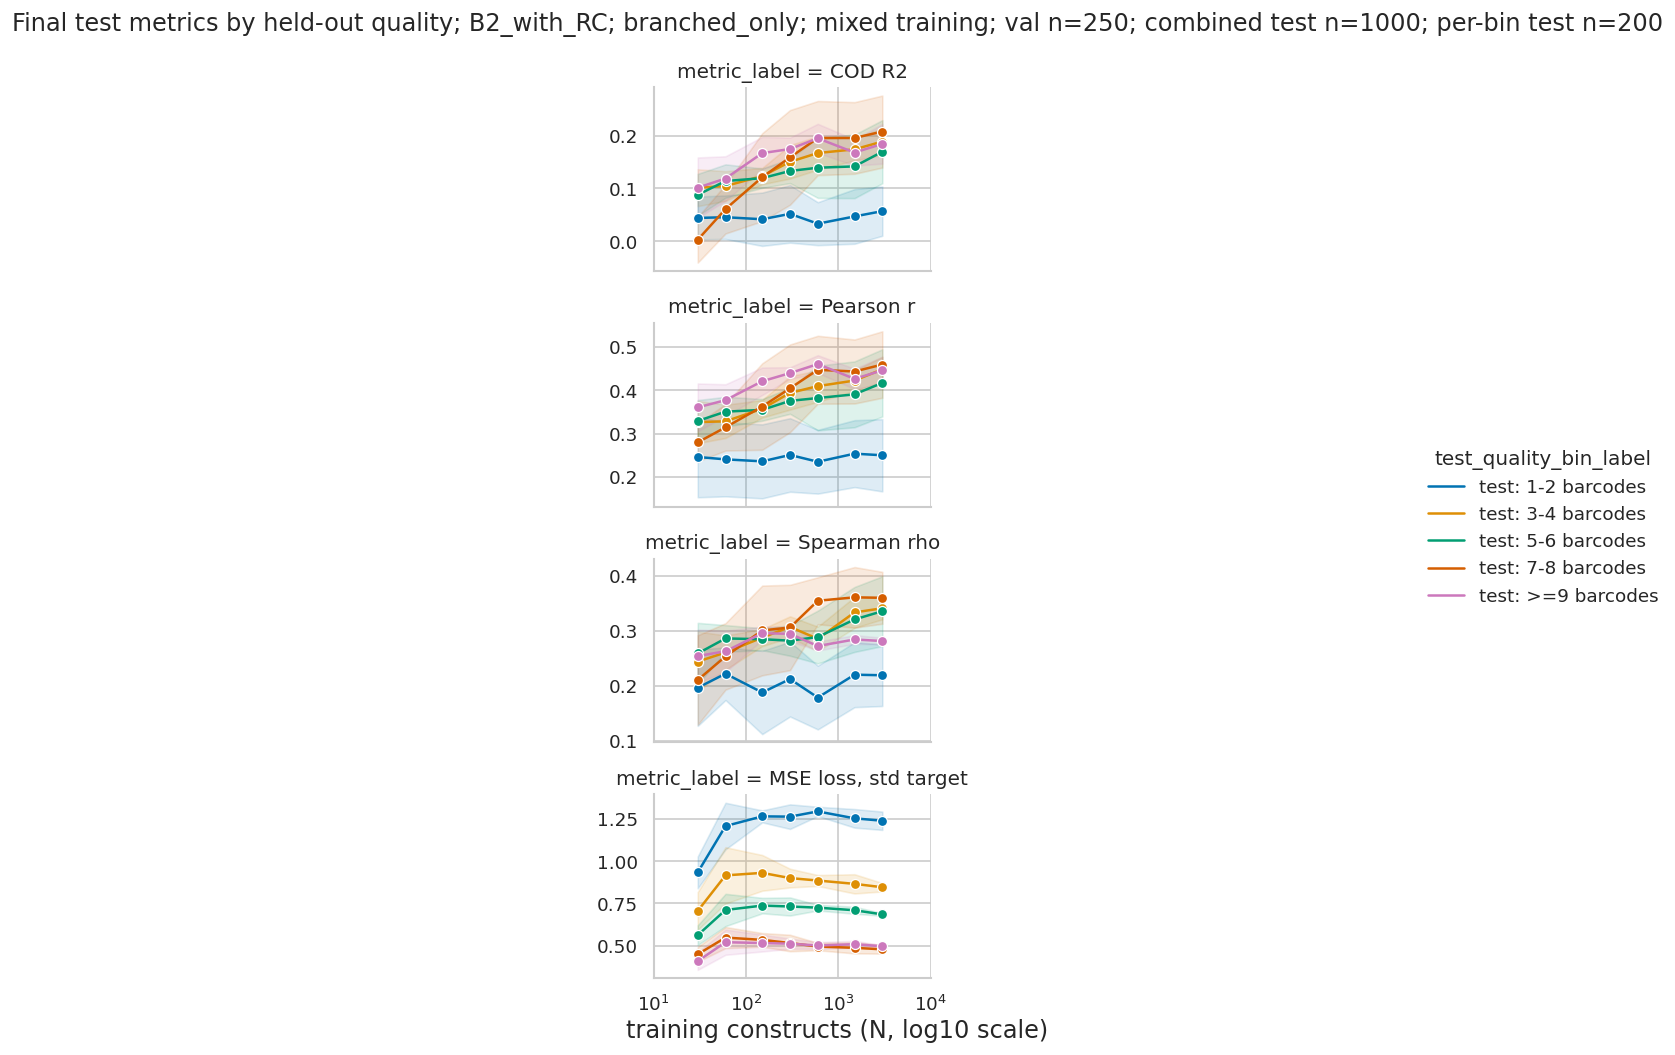

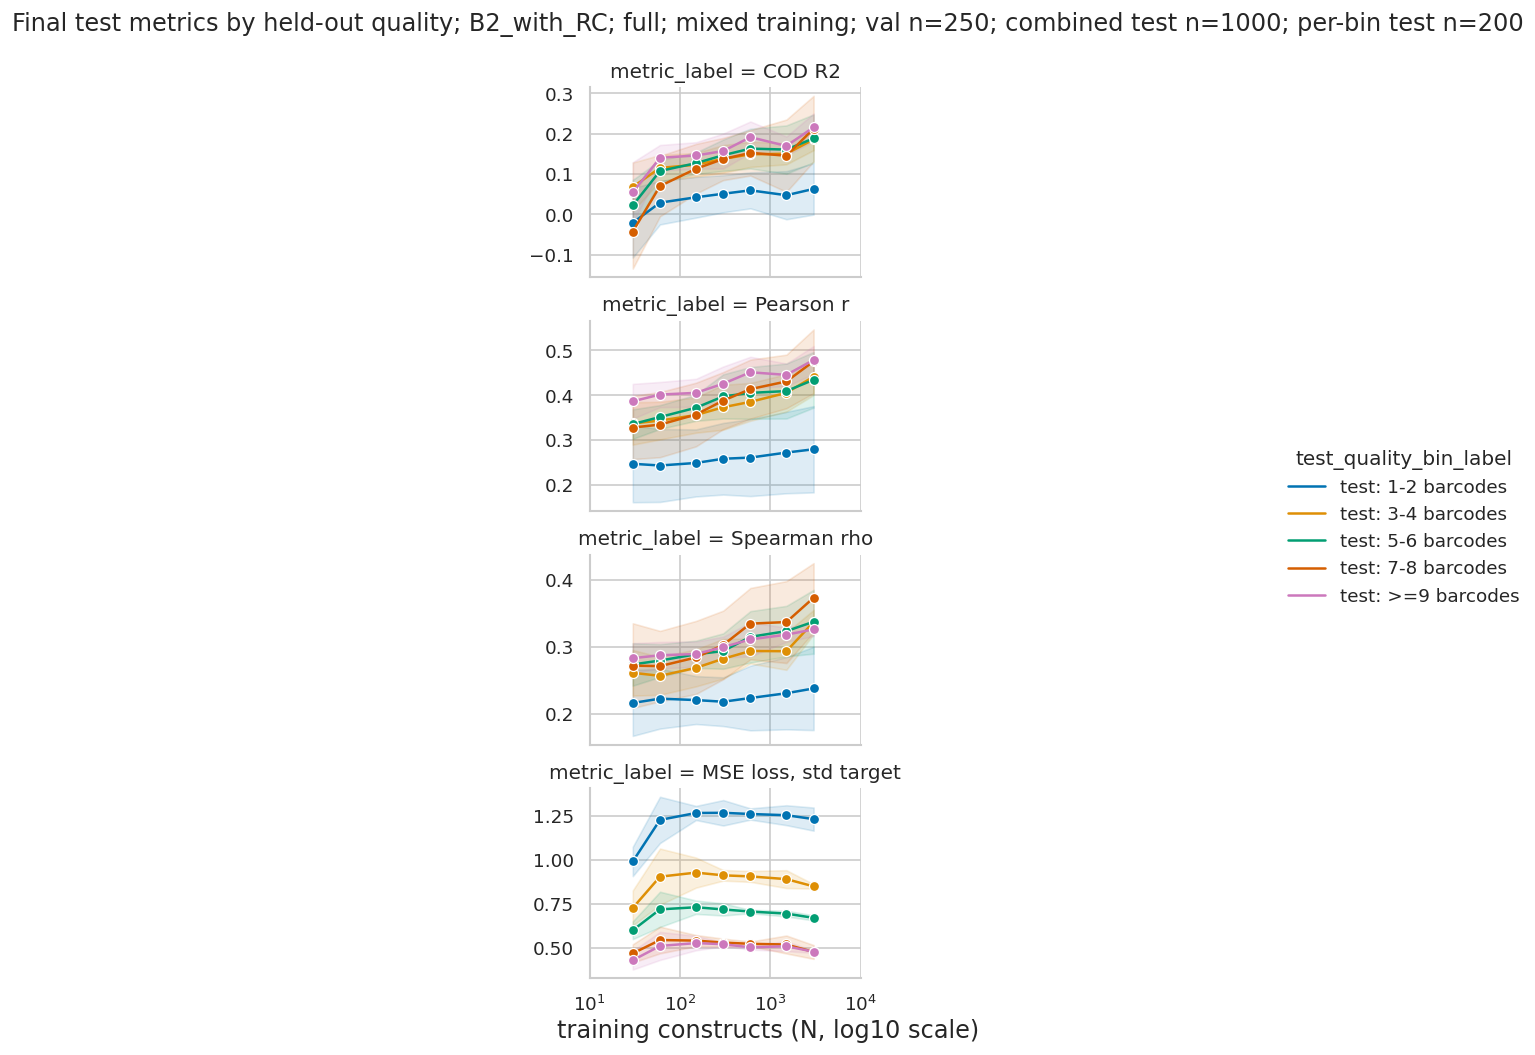

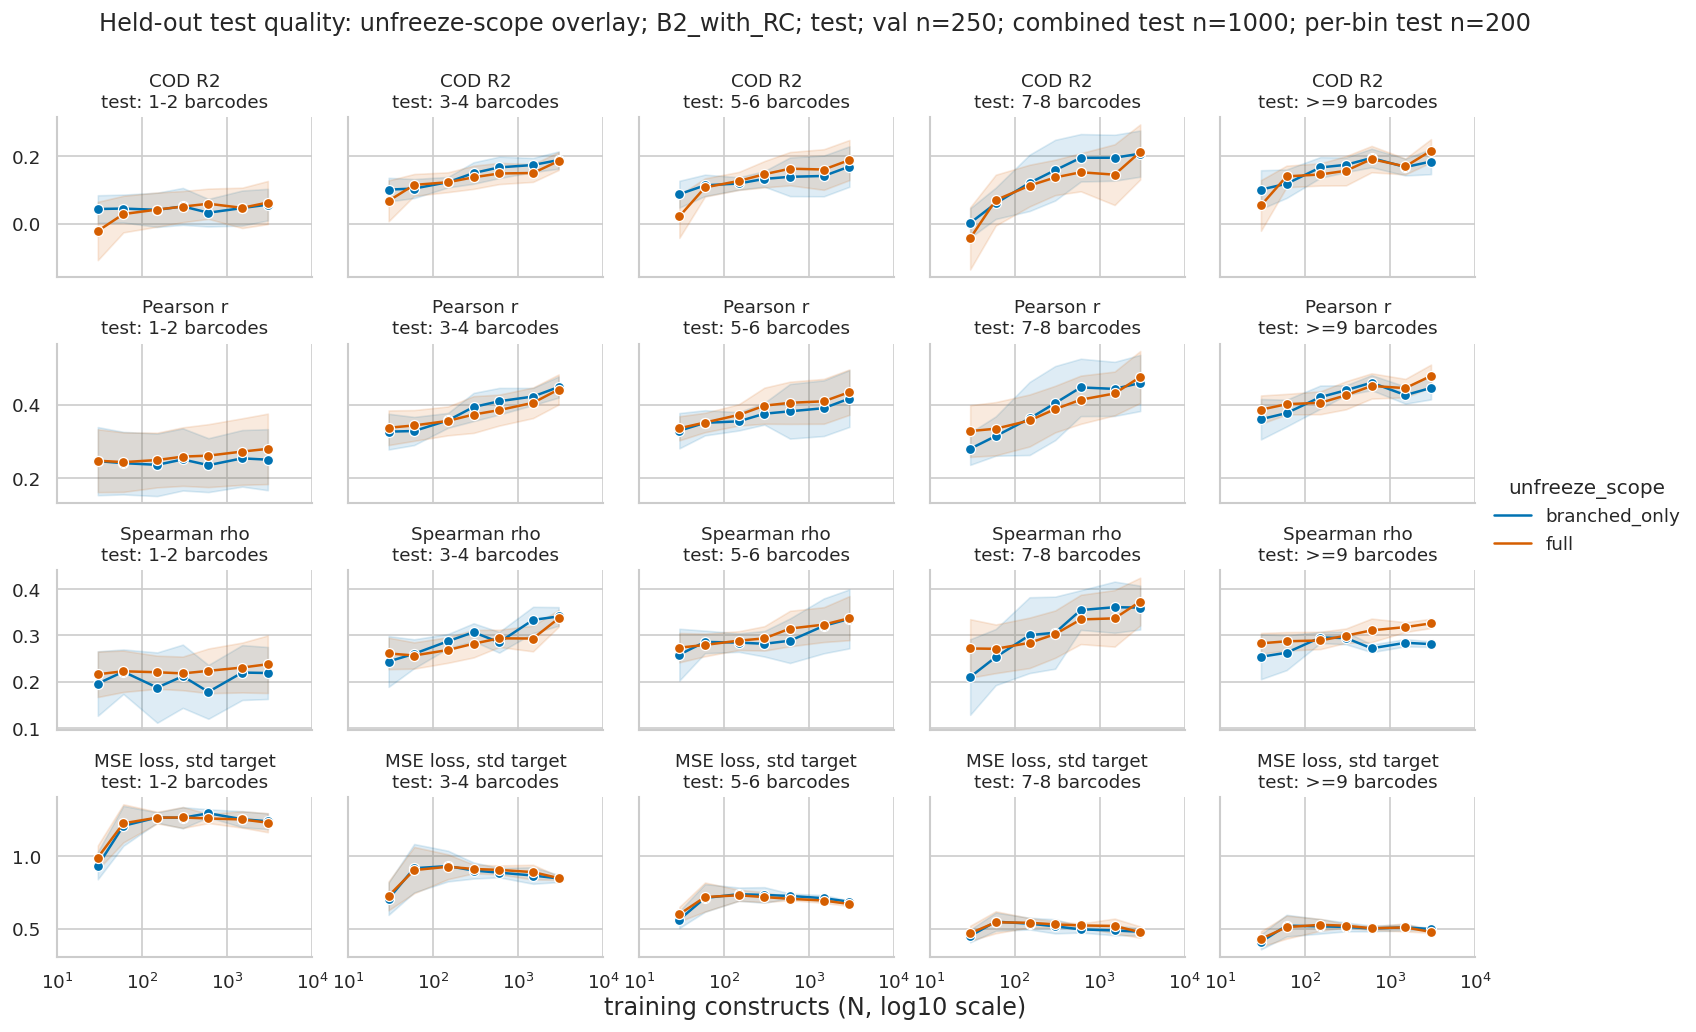

In [8]:
def plot_quality_test_learning_curves(
    quality_long: pd.DataFrame,
    *,
    setting="B2_with_RC",
    unfreeze_scope=DEFAULT_UNFREEZE_SCOPE,
    train_size_min=None,
    metrics=METRIC_ROOTS,
    log_x=True,
    title_context=None,
):
    plot_df = quality_long[
        (quality_long["setting"] == setting)
        & (quality_long["split"] == "test")
        & (quality_long["metric_root"].isin(metrics))
    ].copy()
    if unfreeze_scope is not None and "unfreeze_scope" in plot_df.columns:
        plot_df = plot_df[plot_df["unfreeze_scope"] == unfreeze_scope]
    plot_df = coerce_numeric_column(plot_df, "train_size", positive_only=log_x)
    if train_size_min is not None:
        plot_df = plot_df[plot_df["train_size"] >= train_size_min]
    plot_df = plot_df[np.isfinite(plot_df["value"])]
    if plot_df.empty:
        raise ValueError("No rows after filtering.")
    order = [label for label in QUALITY_LABEL_ORDER if label in set(plot_df["test_quality_bin_label"].astype(str))]
    metric_order = [METRIC_SPECS[m]["label"] for m in metrics]
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="test_quality_bin_label",
        hue_order=order,
        palette=QUALITY_PALETTE,
        row="metric_label",
        row_order=metric_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        err_kws={"alpha": ERROR_BAND_ALPHA},
        height=2.25,
        aspect=1.65,
        facet_kws={"sharey": "row", "sharex": True},
    )
    if log_x:
        for ax in g.axes.flat:
            apply_log10_xaxis(ax, plot_df["train_size"])
    g.set_axis_labels("", "")
    g.fig.supxlabel("training constructs (N, log10 scale)" if log_x else "training constructs (N)", y=0.025)
    g.fig.subplots_adjust(top=0.91, bottom=0.085)
    title = f"Final test metrics by held-out quality; {setting}; {unfreeze_scope}; mixed training"
    g.fig.suptitle(append_title_context(title, title_context))
    return g


def plot_quality_scope_comparison(
    quality_long: pd.DataFrame,
    *,
    setting="B2_with_RC",
    split="test",
    metrics=METRIC_ROOTS,
    log_x=True,
    title_context=None,
):
    plot_df = quality_long[
        (quality_long["setting"] == setting)
        & (quality_long["split"] == split)
        & (quality_long["metric_root"].isin(metrics))
        & (quality_long["unfreeze_scope"].isin(UNFREEZE_SCOPE_ORDER))
    ].copy()
    plot_df = coerce_numeric_column(plot_df, "train_size", positive_only=log_x)
    plot_df = plot_df[np.isfinite(plot_df["value"])]
    if plot_df.empty:
        raise ValueError("No scope-comparison rows after filtering.")
    quality_order = [label for label in QUALITY_LABEL_ORDER if label in set(plot_df["test_quality_bin_label"].astype(str))]
    metric_order = [METRIC_SPECS[m]["label"] for m in metrics]
    scope_palette = {"branched_only": "#0072B2", "full": "#D55E00"}
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="value",
        hue="unfreeze_scope",
        hue_order=[scope for scope in UNFREEZE_SCOPE_ORDER if scope in set(plot_df["unfreeze_scope"])],
        palette=scope_palette,
        col="test_quality_bin_label",
        col_order=quality_order,
        row="metric_label",
        row_order=metric_order,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        err_kws={"alpha": ERROR_BAND_ALPHA},
        facet_kws={"sharex": True, "sharey": "row"},
        height=2.2,
        aspect=1.18,
    )
    if log_x:
        for ax in g.axes.flat:
            apply_log10_xaxis(ax, plot_df["train_size"])
    g.set_axis_labels("", "")
    g.set_titles(template="{row_name}\n{col_name}", size=11)
    g.fig.supxlabel("training constructs (N, log10 scale)" if log_x else "training constructs (N)", y=0.025)
    g.fig.subplots_adjust(top=0.88, bottom=0.085, hspace=0.42, wspace=0.14)
    title = f"Held-out test quality: unfreeze-scope overlay; {setting}; {split}"
    g.fig.suptitle(append_title_context(title, title_context))
    return g


for unfreeze_scope in SCOPES_TO_PLOT:
    g = plot_quality_test_learning_curves(
        quality_test_long,
        setting="B2_with_RC",
        unfreeze_scope=unfreeze_scope,
        log_x=True,
        title_context=quality_size_context,
    )
    plt.show()

g = plot_quality_scope_comparison(
    quality_test_long,
    setting="B2_with_RC",
    log_x=True,
    title_context=quality_size_context,
)
plt.show()


### Quality-Bin Deltas

This table and plot compare each lower-quality test bin against the `test: >=9 barcodes` bin at the same seed, unfreeze scope, and train size. Positive still means "better than the >=9 reference"; for loss the sign is flipped so positive is always beneficial.

,unfreeze_scope,train_size,candidate_label,metric_label,mean_benefit_delta,se,n
96,branched_only,3000.0,test: 1-2 barcodes,COD R2,-0.127294,0.055937,3
100,branched_only,3000.0,test: 3-4 barcodes,COD R2,0.004406,0.061327,3
104,branched_only,3000.0,test: 5-6 barcodes,COD R2,-0.014828,0.034554,3
108,branched_only,3000.0,test: 7-8 barcodes,COD R2,0.023359,0.094559,3
97,branched_only,3000.0,test: 1-2 barcodes,"MSE loss, std target",-0.742962,0.058867,3
101,branched_only,3000.0,test: 3-4 barcodes,"MSE loss, std target",-0.349311,0.021153,3
105,branched_only,3000.0,test: 5-6 barcodes,"MSE loss, std target",-0.188529,0.013464,3
109,branched_only,3000.0,test: 7-8 barcodes,"MSE loss, std target",0.018261,0.027199,3
98,branched_only,3000.0,test: 1-2 barcodes,Pearson r,-0.195629,0.078905,3
102,branched_only,3000.0,test: 3-4 barcodes,Pearson r,0.002440,0.056903,3


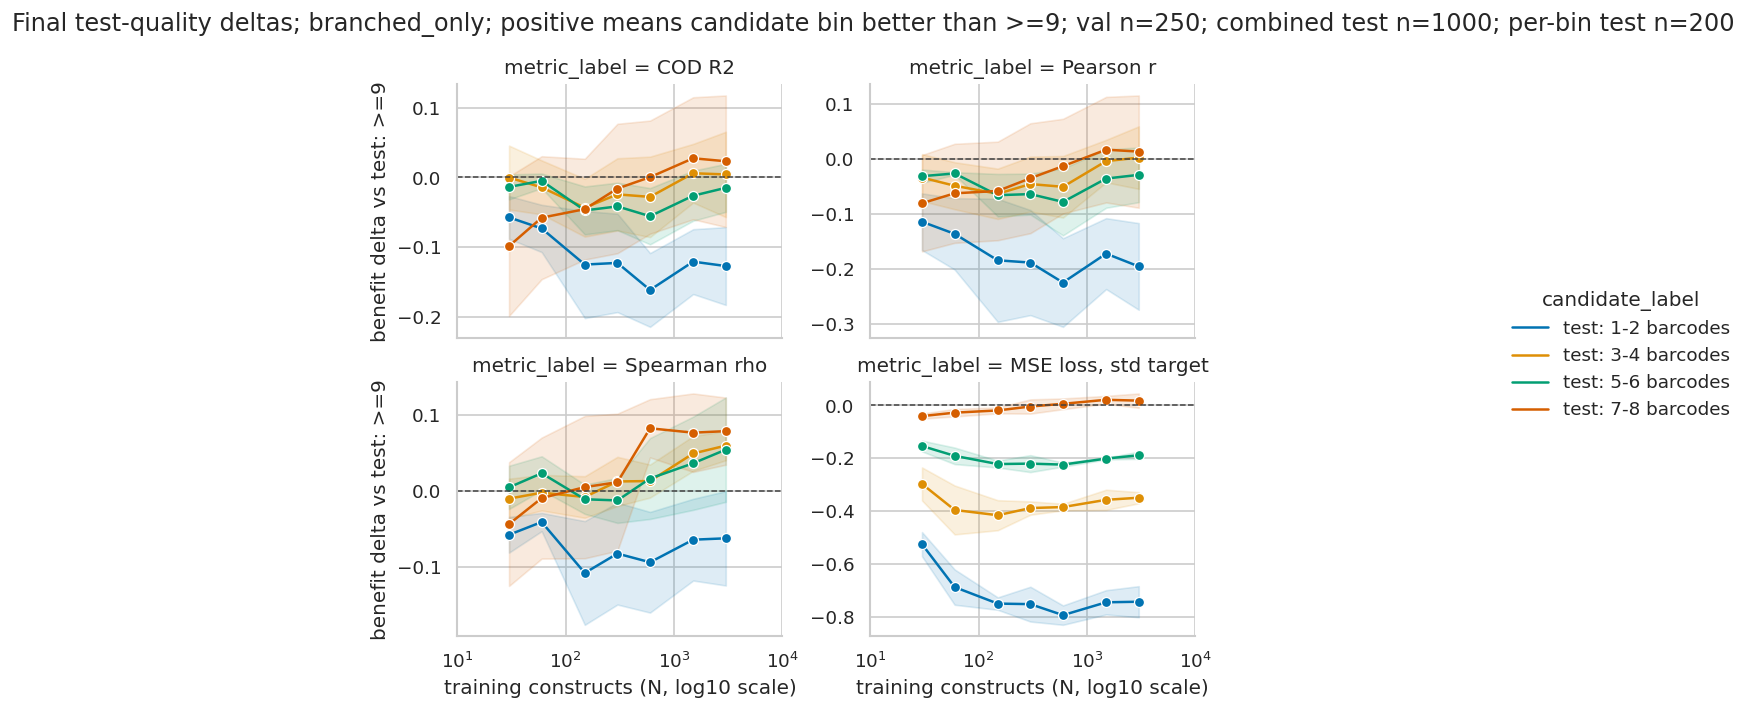

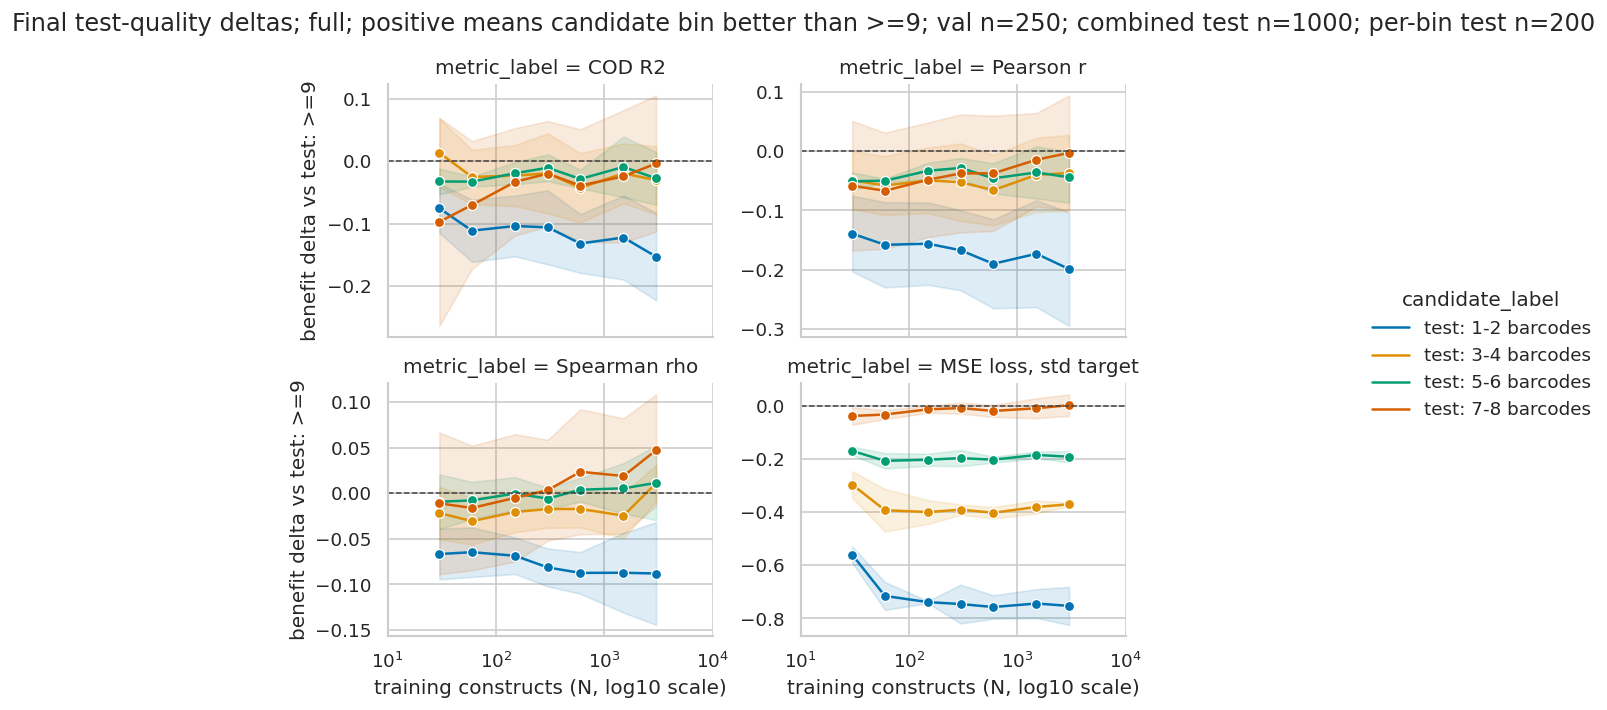

In [9]:
def compute_quality_deltas(
    frame: pd.DataFrame,
    *,
    reference_label="test: >=9 barcodes",
    metrics=METRIC_ROOTS,
) -> pd.DataFrame:
    key_cols = [
        "run_key",
        "run_label",
        "seed",
        "setting",
        "init_head",
        "unfreeze_scope",
        "train_sampling_mode",
        "train_size",
    ]
    key_cols = [col for col in key_cols if col in frame.columns]
    records = []
    for metric_root in metrics:
        metric_col = METRIC_SPECS[metric_root]["cols"]["test"]
        wide = frame.pivot_table(
            index=key_cols,
            columns="test_quality_bin_label",
            values=metric_col,
            aggfunc="first",
            observed=True,
        )
        if reference_label not in wide.columns:
            continue
        for candidate_label in QUALITY_LABEL_ORDER:
            if candidate_label == reference_label or candidate_label not in wide.columns:
                continue
            delta = wide[candidate_label] - wide[reference_label]
            part = delta.rename("raw_delta").reset_index().dropna(subset=["raw_delta"])
            part["candidate_label"] = candidate_label
            part["reference_label"] = reference_label
            part["metric_root"] = metric_root
            part["metric_label"] = METRIC_SPECS[metric_root]["label"]
            part["higher_is_better"] = METRIC_SPECS[metric_root]["higher_is_better"]
            part["benefit_delta"] = np.where(part["higher_is_better"], part["raw_delta"], -part["raw_delta"])
            records.append(part)
    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()


def plot_quality_deltas(
    quality_deltas: pd.DataFrame,
    *,
    unfreeze_scope=DEFAULT_UNFREEZE_SCOPE,
    log_x=True,
    title_context=None,
):
    plot_df = quality_deltas.copy()
    if unfreeze_scope is not None and "unfreeze_scope" in plot_df.columns:
        plot_df = plot_df[plot_df["unfreeze_scope"] == unfreeze_scope]
    plot_df = coerce_numeric_column(plot_df, "train_size", positive_only=log_x)
    if plot_df.empty:
        raise ValueError("No quality-delta rows after filtering.")
    g = sns.relplot(
        data=plot_df,
        x="train_size",
        y="benefit_delta",
        hue="candidate_label",
        hue_order=[label for label in QUALITY_LABEL_ORDER if label != "test: >=9 barcodes"],
        palette=QUALITY_PALETTE,
        col="metric_label",
        col_order=METRIC_LABEL_ORDER,
        col_wrap=2,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        err_kws={"alpha": ERROR_BAND_ALPHA},
        height=3.0,
        aspect=1.25,
        facet_kws={"sharex": True, "sharey": False},
    )
    for ax in g.axes.flat:
        ax.axhline(0, color="0.25", linewidth=0.9, linestyle="--")
        if log_x:
            apply_log10_xaxis(ax, plot_df["train_size"])
    g.set_axis_labels("training constructs (N, log10 scale)" if log_x else "training constructs (N)", "benefit delta vs test: >=9")
    g.fig.subplots_adjust(top=0.88)
    title = f"Final test-quality deltas; {unfreeze_scope}; positive means candidate bin better than >=9"
    g.fig.suptitle(append_title_context(title, title_context))
    return g


quality_deltas = coerce_numeric_column(compute_quality_deltas(quality_runs), "train_size", positive_only=True)
quality_delta_summary = (
    quality_deltas.groupby(["unfreeze_scope", "train_size", "candidate_label", "metric_label"], observed=True, dropna=False)
    .agg(
        mean_benefit_delta=("benefit_delta", "mean"),
        se=("benefit_delta", lambda x: x.std(ddof=1) / np.sqrt(x.count()) if x.count() > 1 else np.nan),
        n=("benefit_delta", "count"),
    )
    .reset_index()
)
display(quality_delta_summary.query("train_size == 3000").sort_values(["unfreeze_scope", "metric_label", "candidate_label"]))

for unfreeze_scope in SCOPES_TO_PLOT:
    g = plot_quality_deltas(
        quality_deltas,
        unfreeze_scope=unfreeze_scope,
        log_x=True,
        title_context=quality_size_context,
    )
    plt.show()


### Per-Epoch Trajectories: Train, Val, Combined Test

These curves diagnose optimization and early stopping. They do not separate the five test quality bins per epoch. If combined-test curves look healthy while low-quality endpoints drop, the quality split is mostly an evaluation-ceiling/noise story.

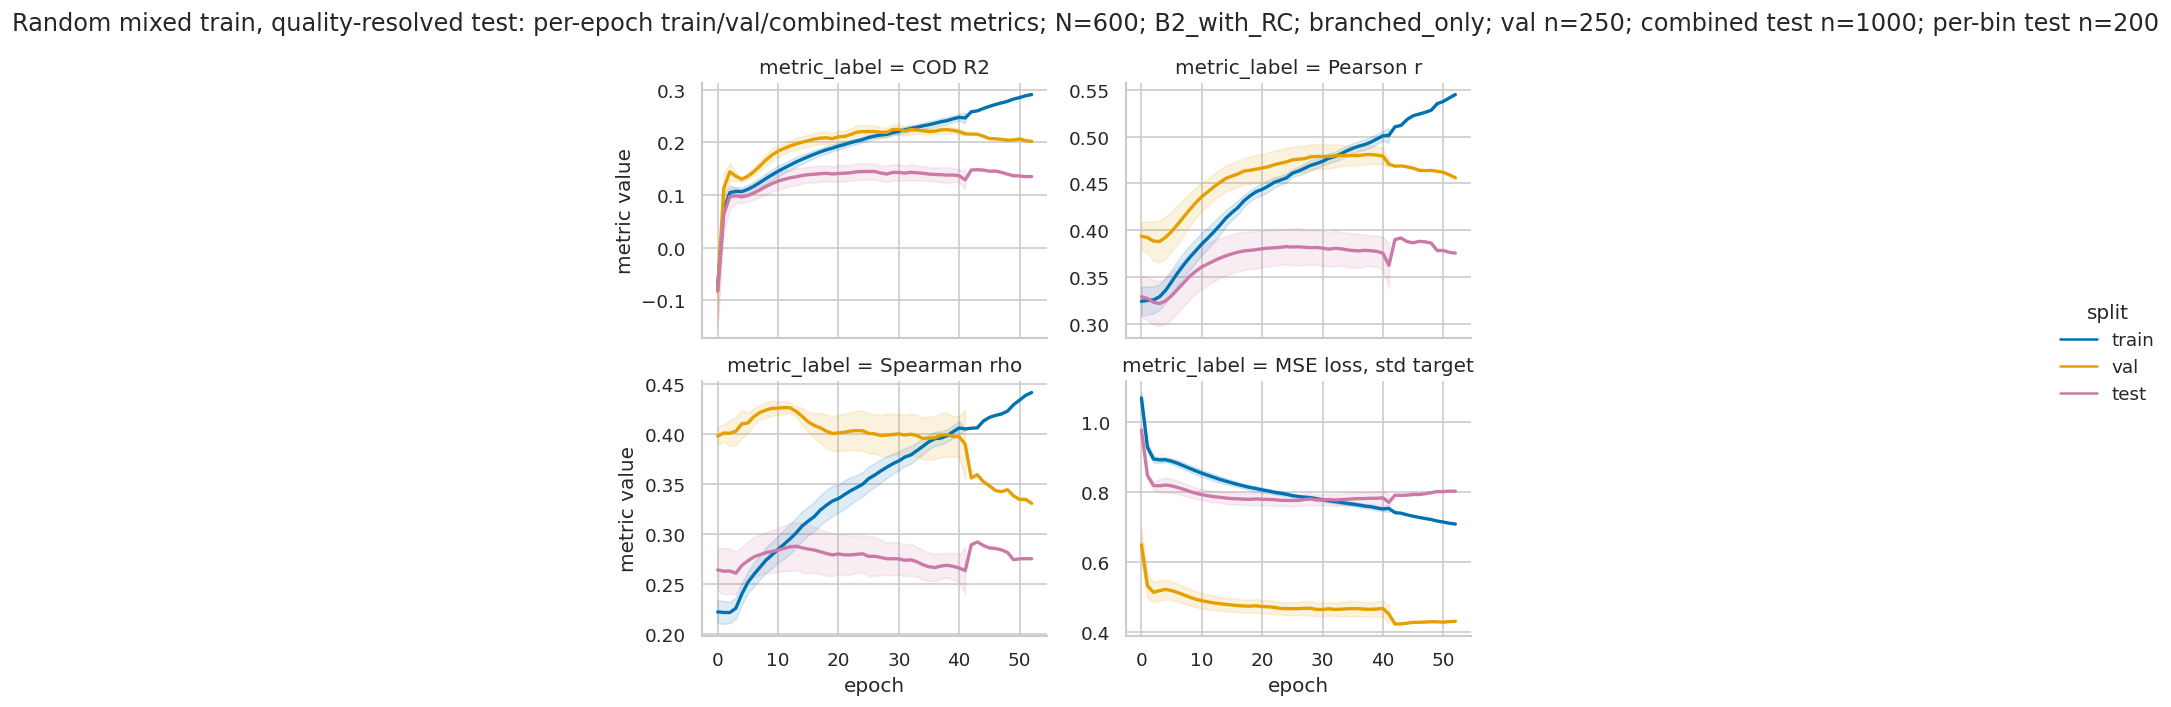

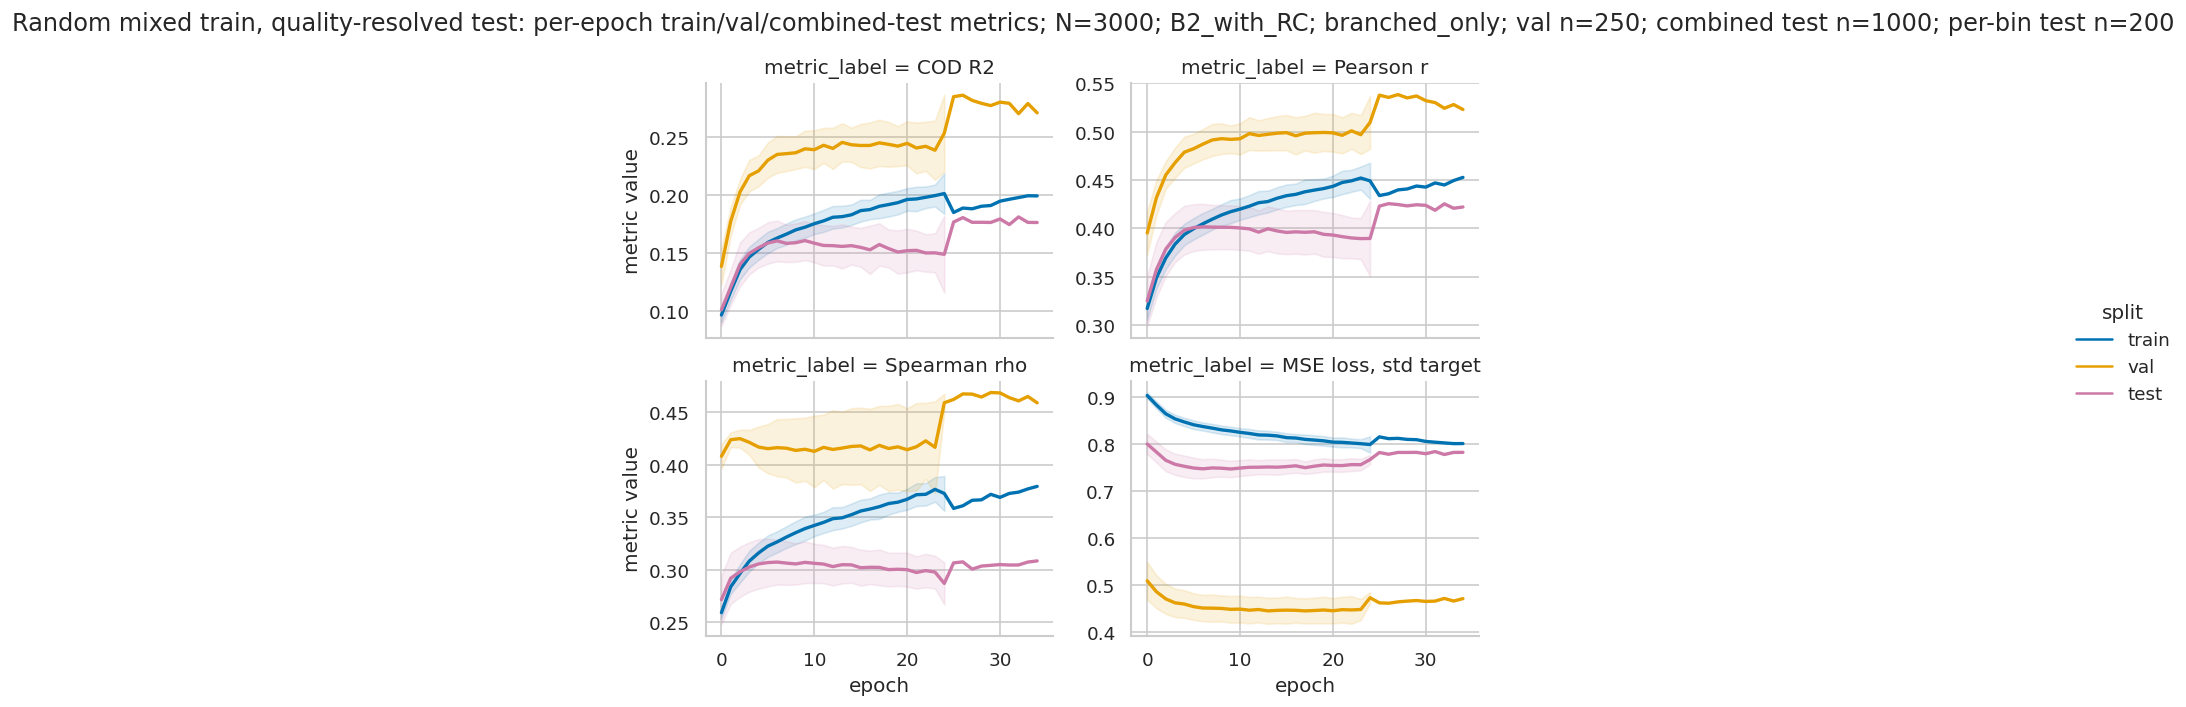

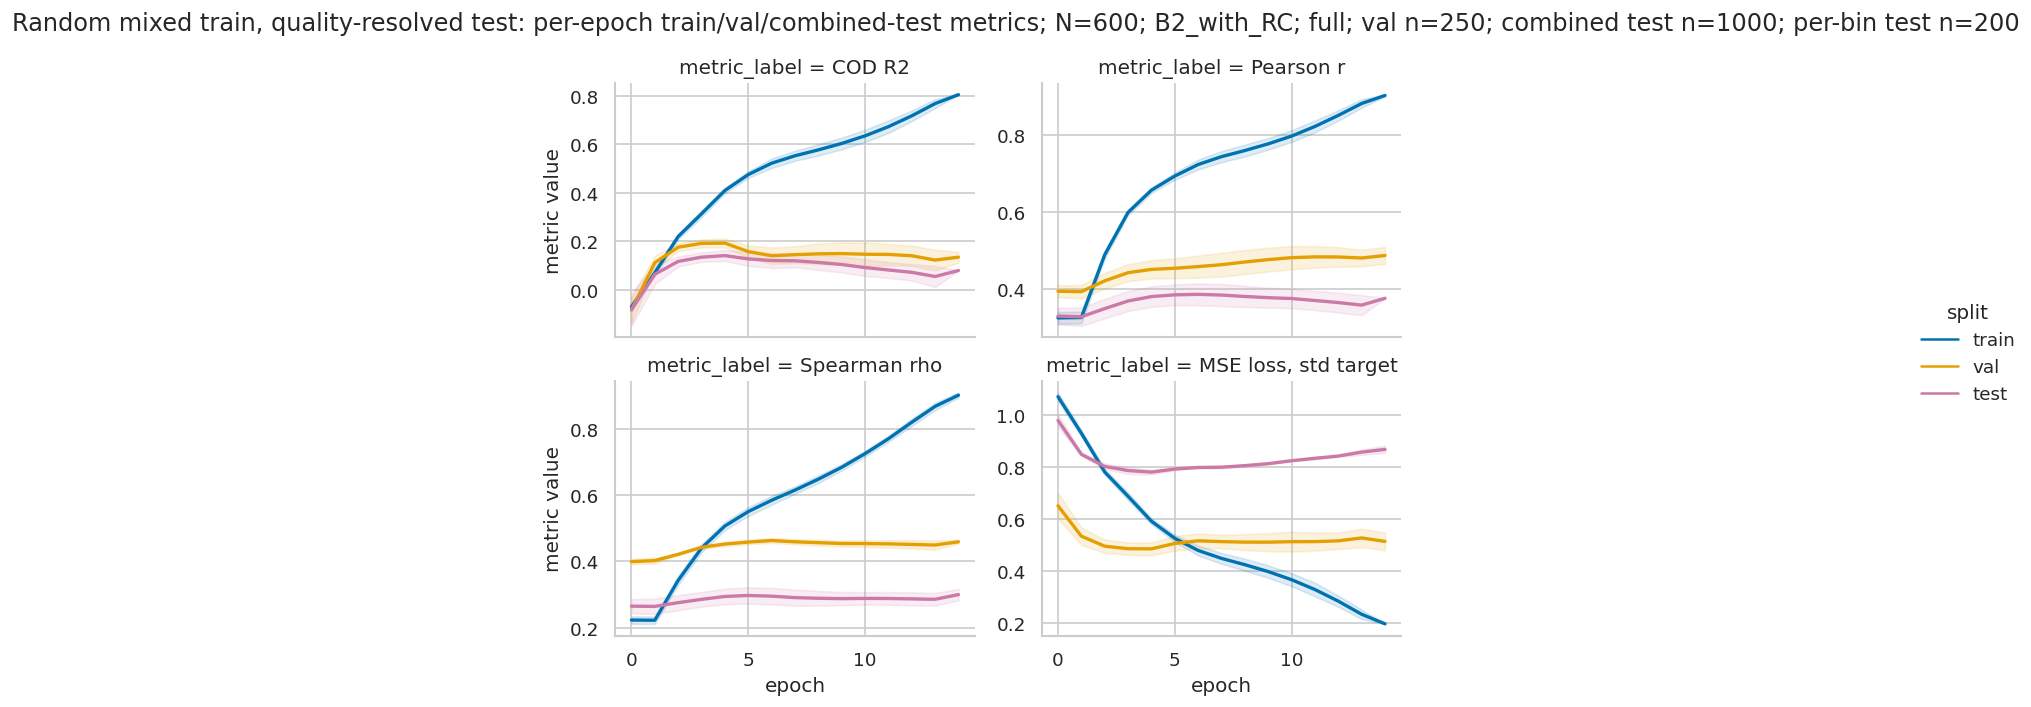

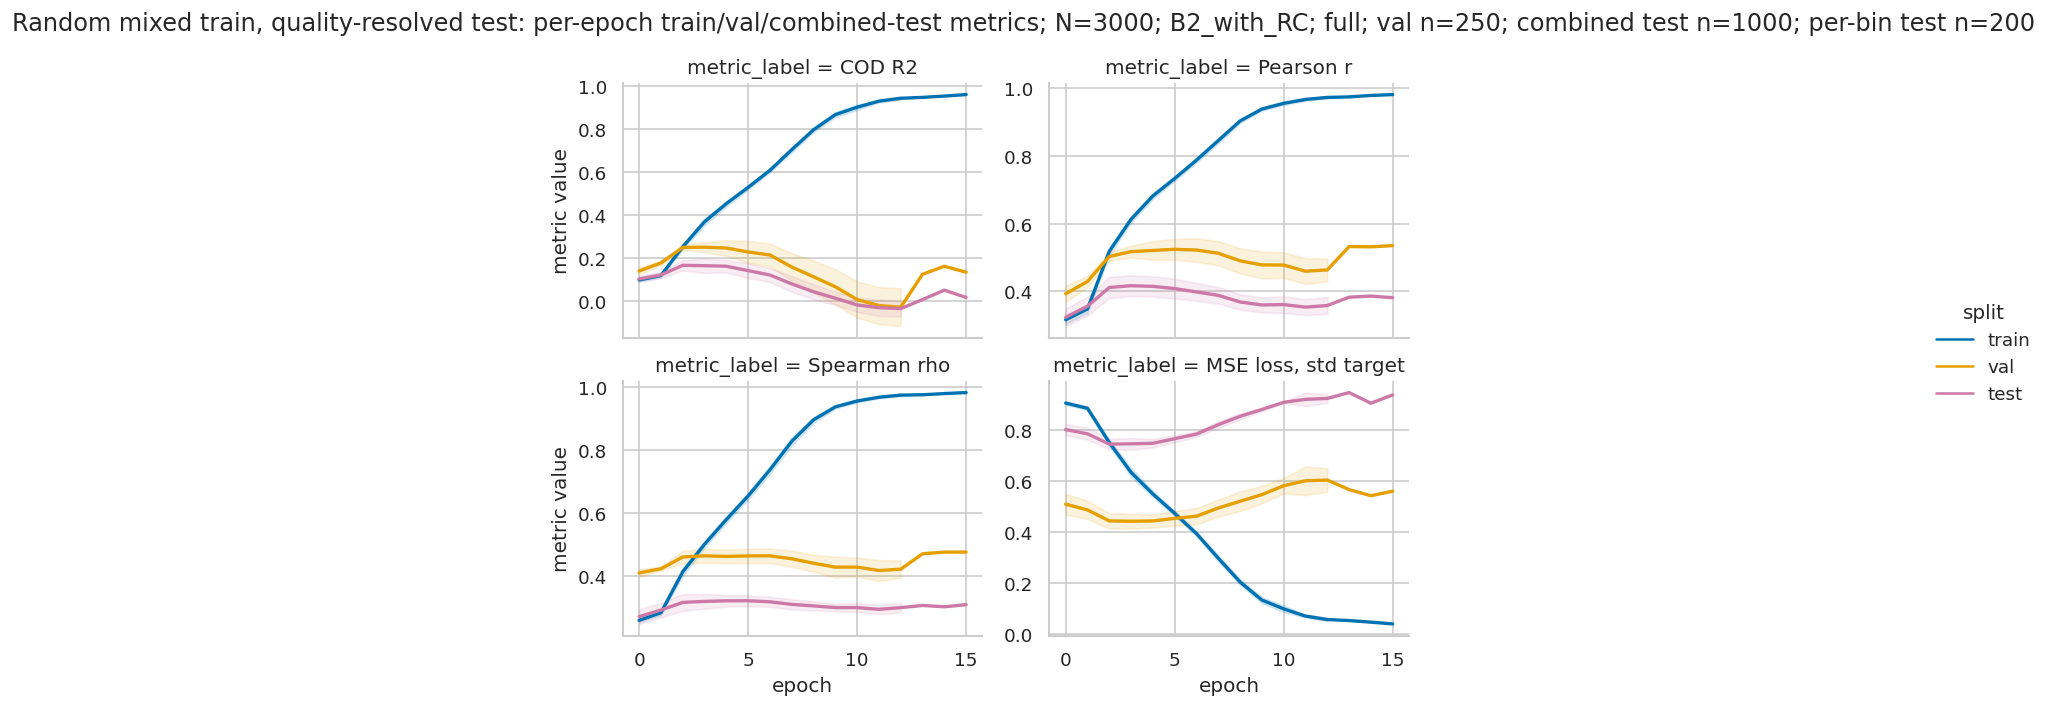

In [10]:
def plot_epoch_trajectories(
    epoch_long: pd.DataFrame,
    *,
    title_prefix: str,
    train_size=3000,
    setting="B2_with_RC",
    unfreeze_scope=DEFAULT_UNFREEZE_SCOPE,
    metrics=METRIC_ROOTS,
    split_values=SPLIT_ORDER,
    epoch_min=None,
    epoch_max=None,
    title_context=None,
):
    plot_df = epoch_long[
        (epoch_long["train_size"] == train_size)
        & (epoch_long["setting"] == setting)
        & (epoch_long["metric_root"].isin(metrics))
        & (epoch_long["split"].isin(split_values))
    ].copy()
    if unfreeze_scope is not None and "unfreeze_scope" in plot_df.columns:
        plot_df = plot_df[plot_df["unfreeze_scope"] == unfreeze_scope]
    if epoch_min is not None:
        plot_df = plot_df[plot_df["epoch"] >= epoch_min]
    if epoch_max is not None:
        plot_df = plot_df[plot_df["epoch"] <= epoch_max]
    plot_df = plot_df[np.isfinite(plot_df["value"])]
    if plot_df.empty:
        raise ValueError("No epoch rows after filtering.")
    g = sns.relplot(
        data=plot_df,
        x="epoch",
        y="value",
        hue="split",
        hue_order=list(split_values),
        palette=SPLIT_PALETTE,
        col="metric_label",
        col_order=[METRIC_SPECS[m]["label"] for m in metrics],
        col_wrap=2,
        kind="line",
        estimator="mean",
        errorbar="se",
        err_kws={"alpha": ERROR_BAND_ALPHA},
        linewidth=2,
        height=3.0,
        aspect=1.25,
        facet_kws={"sharex": True, "sharey": False},
    )
    g.set_axis_labels("epoch", "metric value")
    g.fig.subplots_adjust(top=0.88)
    title = f"{title_prefix}: per-epoch train/val/combined-test metrics; N={train_size}; {setting}; {unfreeze_scope}"
    g.fig.suptitle(append_title_context(title, title_context))
    return g


for unfreeze_scope in SCOPES_TO_PLOT:
    for train_size in [600, 3000]:
        g = plot_epoch_trajectories(
            quality_epoch_long,
            title_prefix=random_quality["label"],
            train_size=train_size,
            setting="B2_with_RC",
            unfreeze_scope=unfreeze_scope,
            title_context=quality_size_context,
        )
        plt.show()


## Endpoint Readout

This table keeps the final `N=3000` endpoint compact while preserving the unfreeze-scope dimension.

In [11]:
quality_endpoint = endpoint_summary_table(
    quality_test_long,
    split="test",
    train_size=3000,
    group_cols=("run_label", "unfreeze_scope", "test_quality_bin_label", "metric_label"),
)
display(quality_endpoint)


,run_label,unfreeze_scope,test_quality_bin_label,metric_label,mean,se,n
0,"Random mixed train, quality-resolved test",branched_only,test: 1-2 barcodes,COD R2,0.056942,0.046666,3
1,"Random mixed train, quality-resolved test",branched_only,test: 1-2 barcodes,"MSE loss, std target",1.239805,0.054166,3
2,"Random mixed train, quality-resolved test",branched_only,test: 1-2 barcodes,Pearson r,0.249978,0.083222,3
3,"Random mixed train, quality-resolved test",branched_only,test: 1-2 barcodes,Spearman rho,0.219053,0.056068,3
4,"Random mixed train, quality-resolved test",branched_only,test: 3-4 barcodes,COD R2,0.188642,0.025492,3
5,"Random mixed train, quality-resolved test",branched_only,test: 3-4 barcodes,"MSE loss, std target",0.846154,0.025008,3
6,"Random mixed train, quality-resolved test",branched_only,test: 3-4 barcodes,Pearson r,0.448047,0.028745,3
7,"Random mixed train, quality-resolved test",branched_only,test: 3-4 barcodes,Spearman rho,0.341104,0.020074,3
8,"Random mixed train, quality-resolved test",branched_only,test: 5-6 barcodes,COD R2,0.169409,0.059758,3
9,"Random mixed train, quality-resolved test",branched_only,test: 5-6 barcodes,"MSE loss, std target",0.685373,0.007945,3


## Notes to Carry Into Discussion

- Compare quality bins within the same unfreeze scope first; then use the scope-overlay plot to ask whether `full` changes sensitivity to held-out label quality.
- If low-quality test bins depress all metrics while train/val/combined-test trajectories look healthy, the random-quality run is mostly telling us about evaluation ceiling/noise.
- A next run would need per-quality per-epoch logging only if we need to distinguish early-stopping sensitivity by held-out quality.